In [177]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

In [178]:
df_exames = pd.read_csv('./datasets/exame_diabetes.csv')

df_exames.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_paciente  110 non-null    int64  
 1   genero       110 non-null    object 
 2   idade        110 non-null    int64  
 3   peso         110 non-null    float64
 4   altura       110 non-null    float64
 5   resultado    110 non-null    int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 5.3+ KB


In [179]:
df_exames['genero'].unique()

array(['M', 'F'], dtype=object)

In [180]:
df_exames.drop(columns=['id_paciente'], axis=1, inplace=True)

In [181]:
df_exames

,genero,idade,peso,altura,resultado
0,M,25,68.0,1.75,95
1,F,34,55.0,1.60,25
2,M,45,85.0,1.78,65
3,F,29,72.0,1.65,80
4,F,19,60.0,1.70,20
...,...,...,...,...,...
105,M,52,92.0,1.80,77
106,F,38,49.0,1.55,28
107,M,41,77.0,1.73,50
108,F,27,65.0,1.60,60


In [182]:
df_exames['altura'] = df_exames['altura'] * 100

In [183]:
df_exames = pd.get_dummies(df_exames, columns=['genero'], dtype='int64') 

In [184]:
df_exames

,idade,peso,altura,resultado,genero_F,genero_M
0,25,68.0,175.0,95,0,1
1,34,55.0,160.0,25,1,0
2,45,85.0,178.0,65,0,1
3,29,72.0,165.0,80,1,0
4,19,60.0,170.0,20,1,0
...,...,...,...,...,...,...
105,52,92.0,180.0,77,0,1
106,38,49.0,155.0,28,1,0
107,41,77.0,173.0,50,0,1
108,27,65.0,160.0,60,1,0


<Axes: >

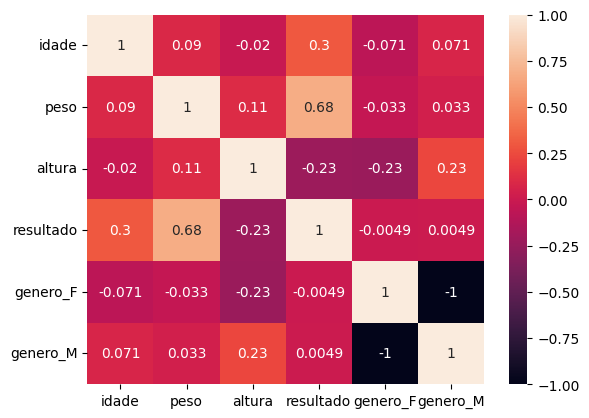

In [185]:
# Correlação de Pearson vai de 1 a -1
sns.heatmap(df_exames.corr(), vmin=-1, vmax=1, annot=True)

<Axes: >

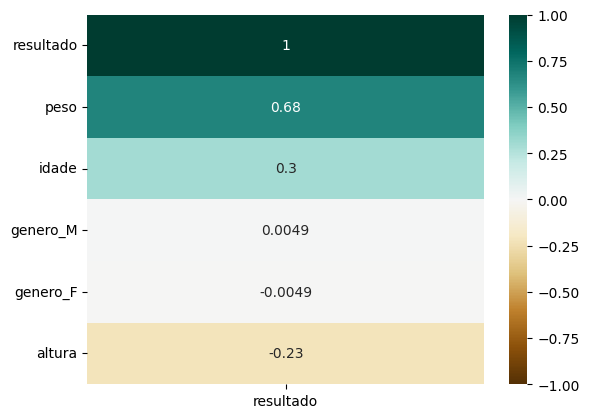

In [186]:
sns.heatmap(df_exames.corr()[['resultado']].sort_values(by='resultado', ascending=False), vmin=-1, vmax=1, annot=True, cmap='BrBG')

array([[<Axes: xlabel='idade', ylabel='idade'>,
        <Axes: xlabel='peso', ylabel='idade'>,
        <Axes: xlabel='altura', ylabel='idade'>,
        <Axes: xlabel='resultado', ylabel='idade'>,
        <Axes: xlabel='genero_F', ylabel='idade'>,
        <Axes: xlabel='genero_M', ylabel='idade'>],
       [<Axes: xlabel='idade', ylabel='peso'>,
        <Axes: xlabel='peso', ylabel='peso'>,
        <Axes: xlabel='altura', ylabel='peso'>,
        <Axes: xlabel='resultado', ylabel='peso'>,
        <Axes: xlabel='genero_F', ylabel='peso'>,
        <Axes: xlabel='genero_M', ylabel='peso'>],
       [<Axes: xlabel='idade', ylabel='altura'>,
        <Axes: xlabel='peso', ylabel='altura'>,
        <Axes: xlabel='altura', ylabel='altura'>,
        <Axes: xlabel='resultado', ylabel='altura'>,
        <Axes: xlabel='genero_F', ylabel='altura'>,
        <Axes: xlabel='genero_M', ylabel='altura'>],
       [<Axes: xlabel='idade', ylabel='resultado'>,
        <Axes: xlabel='peso', ylabel='resultado'>,


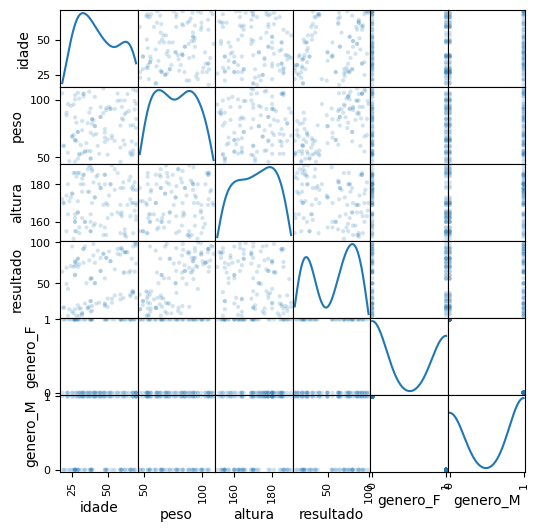

In [187]:
pd.plotting.scatter_matrix(df_exames, alpha=0.2, figsize=(6, 6), diagonal='kde')

array([[<Axes: title={'center': 'idade'}>,
        <Axes: title={'center': 'peso'}>,
        <Axes: title={'center': 'altura'}>],
       [<Axes: title={'center': 'resultado'}>,
        <Axes: title={'center': 'genero_F'}>,
        <Axes: title={'center': 'genero_M'}>]], dtype=object)

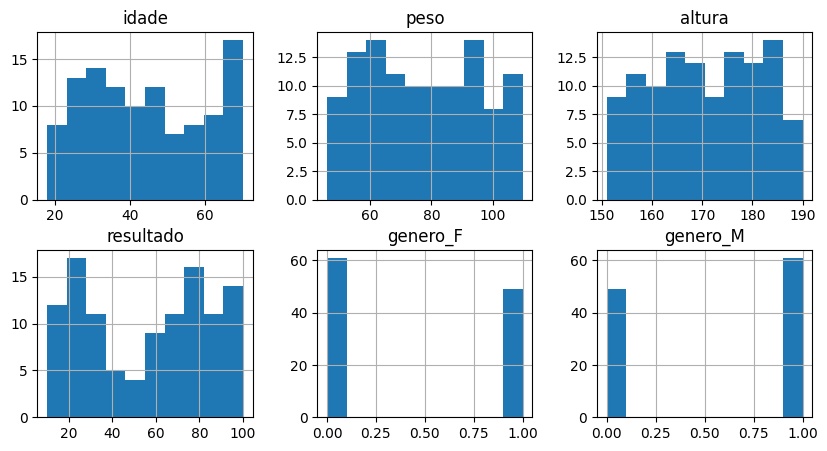

In [188]:
df_exames.hist(layout=(2,3), figsize=(10,5))

In [189]:
# CRIAR UMA FEATURE NOVA
# IMC (ÍNDICE DE MASSA CORPORAL)
# IMC = PESO/ ALTURA**2
df_exames['imc'] = (df_exames['peso'] / ((df_exames['altura']/100) ** 2))


In [190]:
df_exames

,idade,peso,altura,resultado,genero_F,genero_M,imc
0,25,68.0,175.0,95,0,1,22.204082
1,34,55.0,160.0,25,1,0,21.484375
2,45,85.0,178.0,65,0,1,26.827421
3,29,72.0,165.0,80,1,0,26.446281
4,19,60.0,170.0,20,1,0,20.761246
...,...,...,...,...,...,...,...
105,52,92.0,180.0,77,0,1,28.395062
106,38,49.0,155.0,28,1,0,20.395421
107,41,77.0,173.0,50,0,1,25.727555
108,27,65.0,160.0,60,1,0,25.390625


In [191]:
df_exames.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   idade      110 non-null    int64  
 1   peso       110 non-null    float64
 2   altura     110 non-null    float64
 3   resultado  110 non-null    int64  
 4   genero_F   110 non-null    int64  
 5   genero_M   110 non-null    int64  
 6   imc        110 non-null    float64
dtypes: float64(3), int64(4)
memory usage: 6.1 KB


<Axes: >

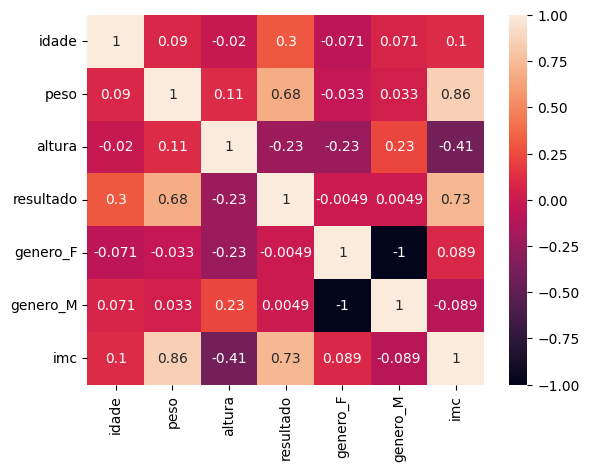

In [192]:
# Correlação de Pearson vai de 1 a -1
sns.heatmap(df_exames.corr(), vmin=-1, vmax=1, annot=True)

<Axes: >

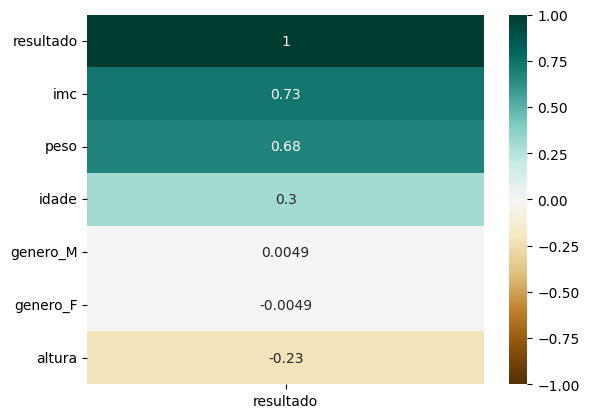

In [193]:
sns.heatmap(df_exames.corr()[['resultado']].sort_values(by='resultado', ascending=False), vmin=-1, vmax=1, annot=True, cmap='BrBG')

array([[<Axes: xlabel='idade', ylabel='idade'>,
        <Axes: xlabel='peso', ylabel='idade'>,
        <Axes: xlabel='altura', ylabel='idade'>,
        <Axes: xlabel='resultado', ylabel='idade'>,
        <Axes: xlabel='genero_F', ylabel='idade'>,
        <Axes: xlabel='genero_M', ylabel='idade'>,
        <Axes: xlabel='imc', ylabel='idade'>],
       [<Axes: xlabel='idade', ylabel='peso'>,
        <Axes: xlabel='peso', ylabel='peso'>,
        <Axes: xlabel='altura', ylabel='peso'>,
        <Axes: xlabel='resultado', ylabel='peso'>,
        <Axes: xlabel='genero_F', ylabel='peso'>,
        <Axes: xlabel='genero_M', ylabel='peso'>,
        <Axes: xlabel='imc', ylabel='peso'>],
       [<Axes: xlabel='idade', ylabel='altura'>,
        <Axes: xlabel='peso', ylabel='altura'>,
        <Axes: xlabel='altura', ylabel='altura'>,
        <Axes: xlabel='resultado', ylabel='altura'>,
        <Axes: xlabel='genero_F', ylabel='altura'>,
        <Axes: xlabel='genero_M', ylabel='altura'>,
        <Axes

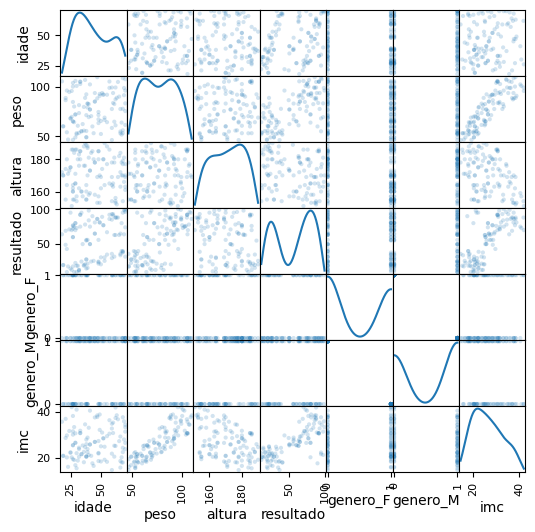

In [194]:
pd.plotting.scatter_matrix(df_exames, alpha=0.2, figsize=(6, 6), diagonal='kde')

array([[<Axes: title={'center': 'idade'}>,
        <Axes: title={'center': 'peso'}>,
        <Axes: title={'center': 'altura'}>],
       [<Axes: title={'center': 'resultado'}>,
        <Axes: title={'center': 'genero_F'}>,
        <Axes: title={'center': 'genero_M'}>],
       [<Axes: title={'center': 'imc'}>, <Axes: >, <Axes: >]],
      dtype=object)

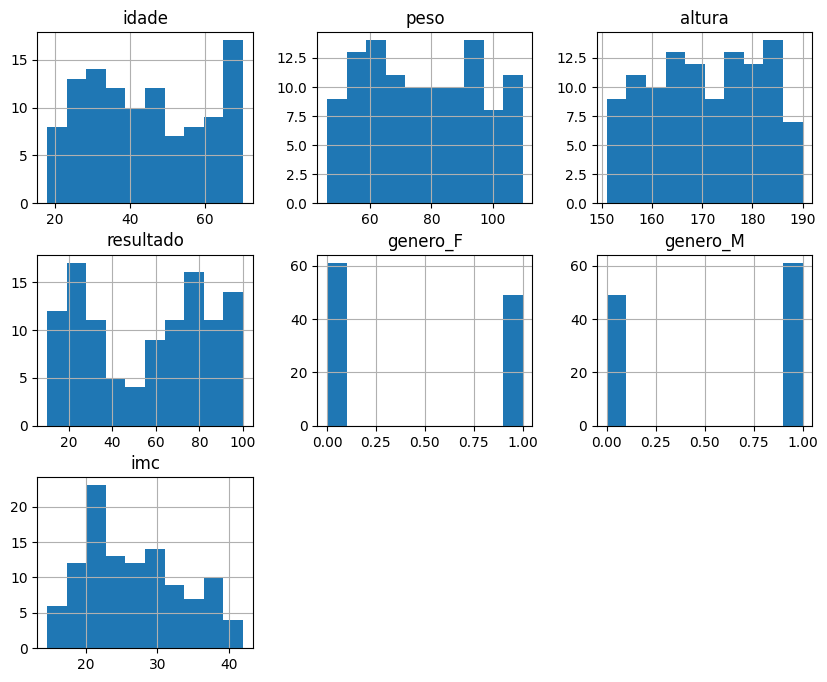

In [195]:
df_exames.hist(layout=(3,3), figsize=(10,8))

In [196]:
dict_regressao = {'tempo_casa': [1, 3, 6, 9, 10, 14, 18], 'salario': [1500, 3000, 4500, 6000, 7000, 8500, 10000]}

In [197]:
df_regressao_simples = pd.DataFrame.from_dict(dict_regressao)

<Axes: xlabel='tempo_casa', ylabel='salario'>

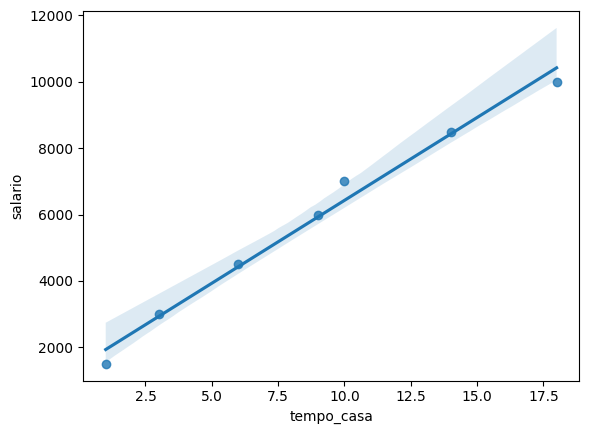

In [198]:
sns.regplot(data=df_regressao_simples, x="tempo_casa", y="salario")

In [199]:
# y = ax + b // função da reta

In [200]:
# Importar bibliotecas do sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score


In [201]:
# Modelo 1 - sem IMC

X = df_exames.drop(columns=['imc', 'resultado']) # Independentes
y = df_exames['resultado'] # Variavel resposta

In [202]:
X

,idade,peso,altura,genero_F,genero_M
0,25,68.0,175.0,0,1
1,34,55.0,160.0,1,0
2,45,85.0,178.0,0,1
3,29,72.0,165.0,1,0
4,19,60.0,170.0,1,0
...,...,...,...,...,...
105,52,92.0,180.0,0,1
106,38,49.0,155.0,1,0
107,41,77.0,173.0,0,1
108,27,65.0,160.0,1,0


In [203]:
y

0      95
1      25
2      65
3      80
4      20
       ..
105    77
106    28
107    50
108    60
109    92
Name: resultado, Length: 110, dtype: int64

In [204]:
# Dividir conjunto entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=51)

In [205]:
X_train

,idade,peso,altura,genero_F,genero_M
99,27,84.6,164.0,0,1
81,57,98.8,165.0,0,1
71,37,88.7,190.0,1,0
9,33,105.0,185.0,0,1
45,38,55.3,164.0,0,1
...,...,...,...,...,...
69,68,77.7,179.0,1,0
73,60,83.6,165.0,1,0
96,70,107.5,177.0,0,1
101,34,55.0,160.0,1,0


In [206]:
X_test

,idade,peso,altura,genero_F,genero_M
103,29,72.0,165.0,1,0
75,50,52.3,169.0,0,1
95,48,74.5,185.0,1,0
83,21,86.4,174.0,0,1
86,64,104.8,169.0,1,0
11,18,105.4,172.0,0,1
14,62,61.0,156.0,0,1
46,57,105.2,186.0,0,1
87,48,63.3,185.0,0,1
65,44,53.1,180.0,0,1


In [207]:
y_train

99     72
81     86
71     21
9      92
45     15
       ..
69     38
73     91
96     96
101    95
57     21
Name: resultado, Length: 77, dtype: int64

In [208]:
y_test

103     80
75      31
95      22
83      49
86      88
11      64
14      63
46      92
87      24
65      26
4       20
62      98
43      93
19     100
88      78
51      89
15      80
56      88
64      18
2       65
32      22
44      39
58      43
80      10
0       95
70      77
82      86
78      63
12      13
97      56
89      95
72      75
90      35
Name: resultado, dtype: int64

In [209]:
# Treinar o algorítmo de regressão Linear - Modelo 1

model_1 = LinearRegression().fit(X_train, y_train)

In [210]:
# Gerar predições do conjunto de testes com base no Modelo 1
y_pred = model_1.predict(X_test)

In [211]:
# Equação da Reta - Regressão Linear
# y = ax + b
model_1.coef_

array([ 0.38410522,  1.16729471, -0.90753512, -1.11250143,  1.11250143])

In [212]:
model_1.intercept_

np.float64(102.18587719693909)

In [213]:
y_pred

array([ 46.51435247,  30.17971872,  38.57988619,  54.30774138,
        94.61516146,  77.1490955 ,  56.74240193,  79.19024867,
        27.73118826,  18.82603687,  24.12808809,  35.29225522,
        85.45025047,  88.08179655,  82.45116689,  74.23542004,
        39.74057782,  93.20744066,   9.23195417,  58.26191369,
        43.11314454,  51.64047526,  60.56939463,  35.76045257,
        33.45840442,  81.26972883,  95.91339014,  58.76675514,
        23.50229205,  58.65797098, 101.90477002,  94.16285855,
        26.52288186])

In [214]:
# R2 Score - de -infinito até 1 o quanto x explica y

model_1.score(X_train, y_train)

0.6354119095736723

In [215]:
# R2 Score - Conjunto de testes

model_1.score(X_test, y_test)

0.49633668147849674

In [216]:
r2_score(y_test, y_pred)

0.49633668147849674

In [217]:
# MAE (Mean Absolute Error)
mean_absolute_error(y_test, y_pred)

14.459675089877912

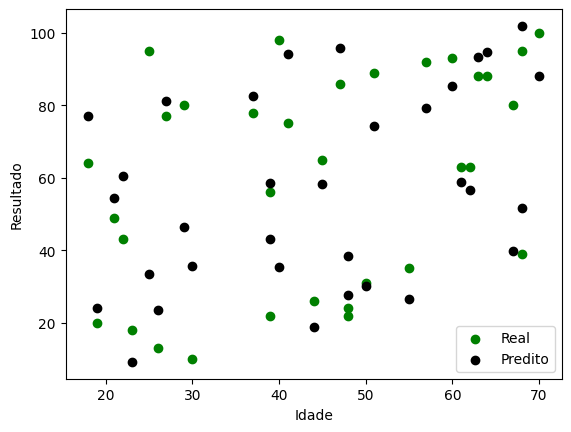

In [218]:
plt.scatter(X_test['idade'], y_test, color='g', label='Real')
plt.scatter(X_test['idade'], y_pred, color='k', label='Predito')
plt.xlabel('Idade')
plt.ylabel('Resultado')
plt.legend()
plt.show()

In [219]:
# Segundo modelo IMC
X = pd.DataFrame(df_exames['imc'])
y = df_exames['resultado']

In [220]:
# Dividir conjunto entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=51)

In [221]:
model_2 = LinearRegression().fit(X_train, y_train)

In [222]:
y_pred = model_2.predict(X_test)

In [223]:
model_2.coef_

array([3.15565608])

In [224]:
model_2.intercept_

np.float64(-30.07844208580994)

In [225]:
# Treinamento
model_2.score(X_train, y_train)

0.5739252802985042

In [226]:
# Teste
model_2.score(X_test, y_test)

0.4259178855743905

In [227]:
mean_absolute_error(y_test, y_pred)

16.60976119720917

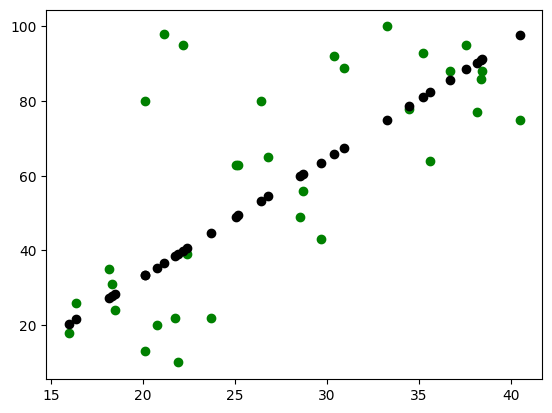

In [228]:
plt.scatter(X_test, y_test, color='g')
plt.scatter(X_test, y_pred, color='k')